In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Ramachandran

In [2]:
run_folder = '/mnt/projects/sne/Gohar/12.PROJECT_Surrogate_Dynamics/surrogate-dynamics/predict_runs/edvae/ala2/10ns/run_1_1'
n_warmup = 100


# real_traj_file = os.path.join(run_folder, 'TFT_real.pdb')
predicted_traj_file = os.path.join(run_folder, 'TFT_predicted.pdb')

In [3]:
# real_traj = mda.Universe(real_traj_file)
predicted_traj = mda.Universe(predicted_traj_file)
predicted_traj.transfer_to_memory()

# residue_real = real_traj.select_atoms('resid 2')
residue_predicted = predicted_traj.select_atoms('resid 2')

/mnt/projects/sne/Gohar/software_deck/pyenv-ml/lib/python3.12/site-packages/MDAnalysis/core/universe.py:743: UserWarning: Reader has no dt information, set to 1.0 ps
  dt=self.trajectory.ts.dt * step,


In [4]:
# Rama_real = Ramachandran(residue_real).run()

Rama_warmup = Ramachandran(residue_predicted).run(stop=n_warmup, step=10)
Rama_predicted_small = Ramachandran(residue_predicted).run(start=n_warmup+1, step=100)
Rama_predicted_full = Ramachandran(residue_predicted).run(start=n_warmup+1, step=1)

In [5]:
rama_warmup_data = (Rama_warmup.angles * np.pi / 180).squeeze()
rama_pred_small_data = (Rama_predicted_small.angles * np.pi / 180).squeeze()
rama_pred_full_data = (Rama_predicted_full.angles * np.pi / 180).squeeze()

/mnt/projects/sne/Gohar/software_deck/pyenv-ml/lib/python3.12/site-packages/MDAnalysis/analysis/dihedrals.py:527: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


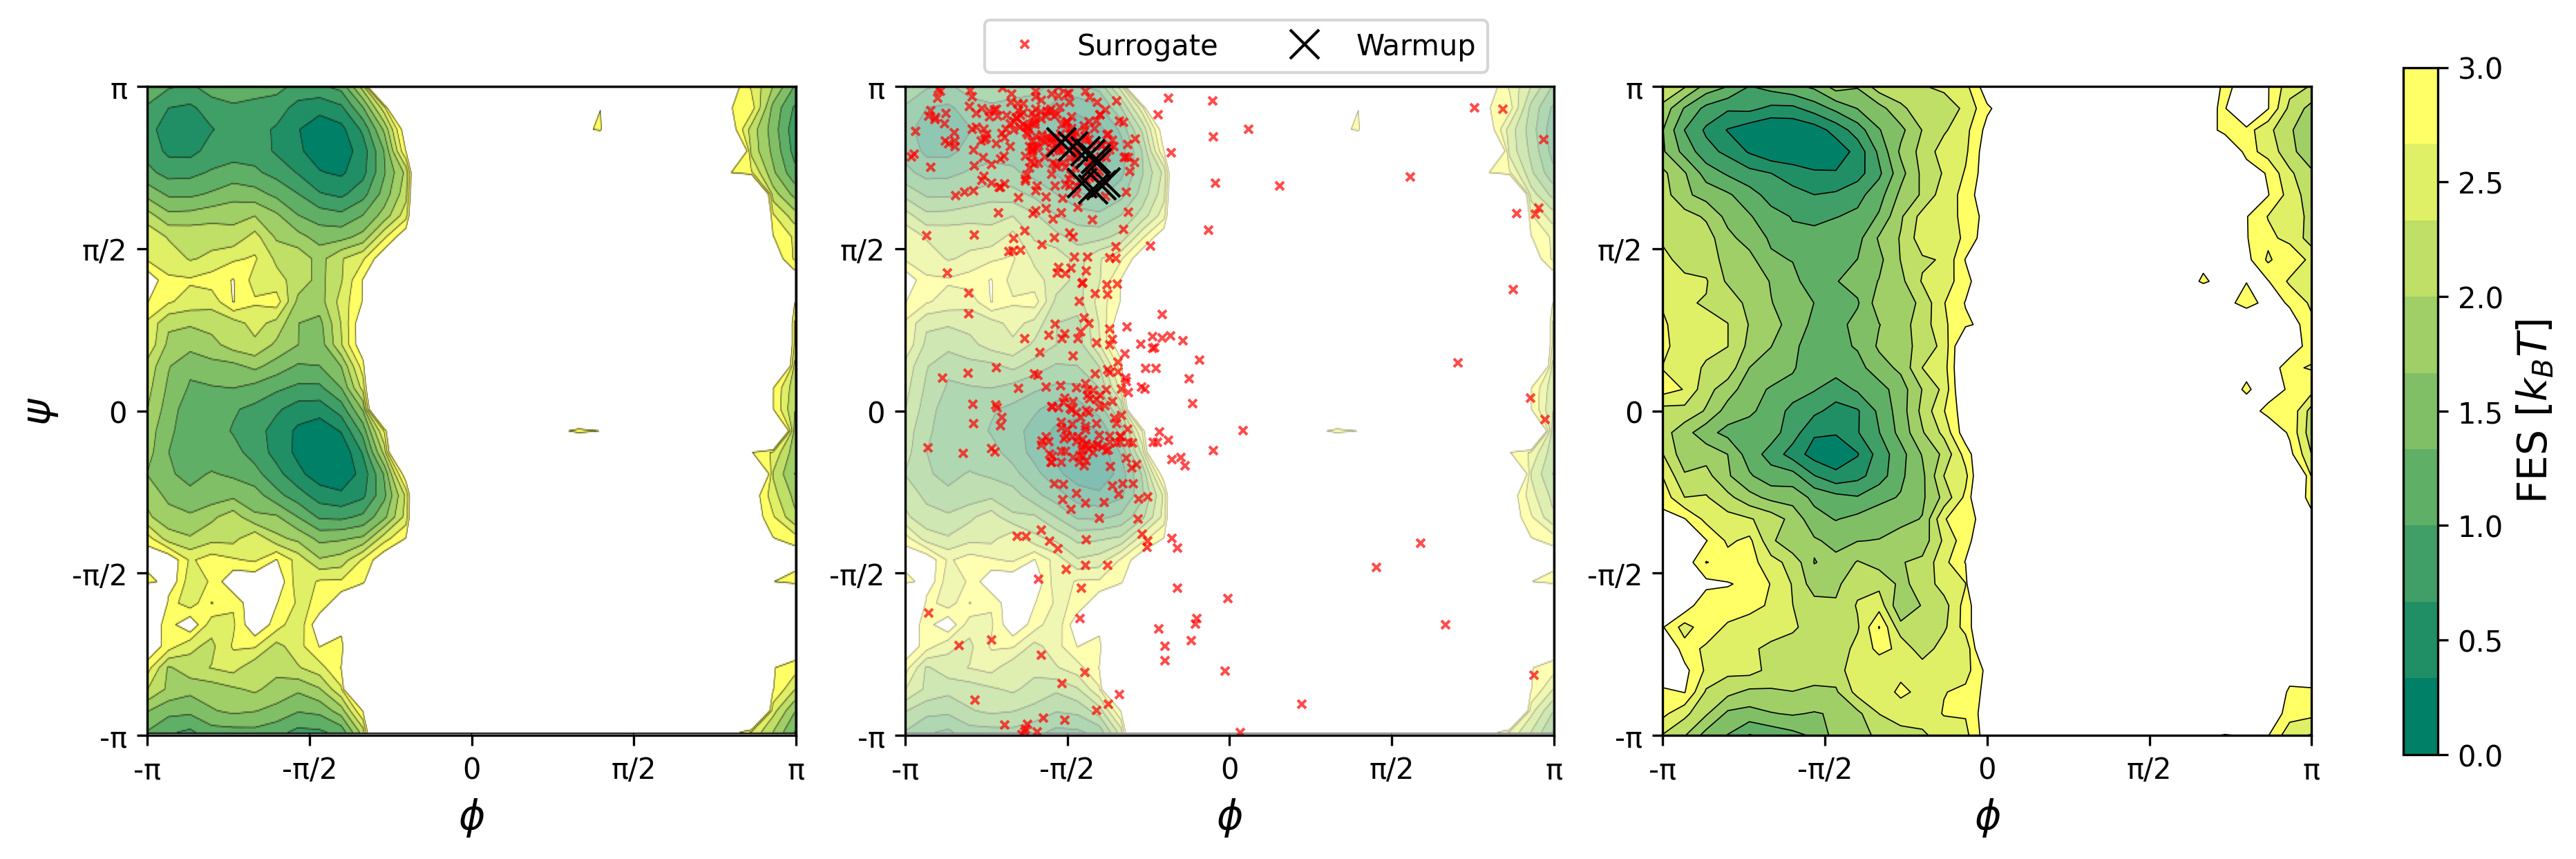

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12,36), dpi=300)
img = plt.imread("../inputs/ala2/rp2_ala2.png")
# Rama_real.plot(ax=ax[0], color='b', marker='s')
# ax[0].set_title('Real')

## Original Ramachandran plot
ax[0].imshow(img, extent=[-np.pi, np.pi, -np.pi, np.pi], alpha=1.0)

## Warmup and Predicted steps on the background of the original Ramachandran plot
ax[1].plot(rama_pred_small_data[:,0], rama_pred_small_data[:,1], 'x', markersize=3, color='r', alpha=0.7)
ax[1].plot(rama_warmup_data[:,0], rama_warmup_data[:,1], 'x', markersize=10, color='black')
ax[1].imshow(img, extent=[-np.pi, np.pi, -np.pi, np.pi], alpha=0.5)
ax[1].legend(['Surrogate', 'Warmup'], loc='lower left', ncols=2, bbox_to_anchor=(0.1, 1))

## Ramachandran plot for the predicted steps
def free_energy_weights(a, b, T, y0, ymax, x0, xmax, w = None):
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], density=True, weights=w)
    free_energy = np.log(free_energy + .000001)
    free_energy = -(0.001987*T) * free_energy
    return free_energy, xedges, yedges

phi, psi = rama_pred_full_data[:,0], rama_pred_full_data[:,1]
dG, xedges, yedges = free_energy_weights(psi, phi, 300, -3.14, 3.14, -3.14, 3.14)
if False:
    dG -= np.amax(dG)
elif True:
    dG -= np.amin(dG)
lmax = 3#np.amax(dG)
lmin = np.amin(dG)
nlevels = 10
levels = np.linspace(lmin, lmax, nlevels)#np.arange(lmin, lmax, (lmax-lmin)/nlevels)
norm = cm.colors.Normalize(vmax=lmax, vmin=lmin)
cmap = cm.summer
x, y = xedges, yedges
dG = np.concatenate((dG, dG[:, 0:1]), axis=1) # periodic boundary
dG = np.concatenate((dG, dG[0:1, :]), axis=0) # periodic boundary

cset1 = ax[2].contourf(x, y, dG, levels, norm=norm, cmap=cmap.resampled(len(levels) - 1))
cset2 = ax[2].contour(x, y, dG, cset1.levels, colors='k',linewidths=0.4) # For contour lines
ax[2].set_aspect('equal')


for i in range(3):
    a = ax[i]
    a.set_xlim(-np.pi, np.pi)
    a.set_ylim(-np.pi, np.pi)
    a.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    a.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    a.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    a.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    a.set_xlabel(r'$\phi$', fontsize=14)
    a.set_ylabel(r'$\psi$', fontsize=14) if i == 0 else None

fig.tight_layout()
cb = fig.colorbar(cset1, ax=ax, pad=0.04, fraction=0.015)
cb.set_ticks(np.linspace(0.0, lmax, 7))
cb.set_label(r'FES $[k_{B}T]$', fontsize=14)
fig.savefig('ramachandran.png', dpi=300, bbox_inches='tight')

